In [ ]:
from lfp_xkit import lfp_xkit

# 1. DEFINE THE PATH FIRST
fif_path = "/lfp_raw/DP02_gain_lfp_raw.fif"

2026-07-25 21:16:42,508 [INFO] lfp_xkit: Loading DP02_gain_lfp_raw.fif
2026-07-25 21:16:42,677 [INFO] lfp_xkit: Bandpass 1-100 Hz
2026-07-25 21:16:42,720 [INFO] lfp_xkit: Soft notch at 60 Hz, max attenuation 1 dB
2026-07-25 21:16:42,723 [INFO] lfp_xkit: T-wave subtraction: DISABLED (Delta-safe) | QRS high-pass: 4.0 Hz
2026-07-25 21:16:42,729 [INFO] lfp_xkit: Dead segments: 0 samples (0.0% of recording) | 0 regions detected
2026-07-25 21:16:42,737 [INFO] lfp_xkit: Channel L1: 74 EKG peaks, thr=1.02005e-05, dead=0.0%, recon=0.0%
2026-07-25 21:16:42,746 [INFO] lfp_xkit: Dead segments: 0 samples (0.0% of recording) | 0 regions detected
2026-07-25 21:16:42,755 [INFO] lfp_xkit: Channel L2: 91 EKG peaks, thr=8.68347e-06, dead=0.0%, recon=0.0%
2026-07-25 21:16:42,764 [INFO] lfp_xkit: Dead segments: 550 samples (2.7% of recording) | 1 regions detected
2026-07-25 21:16:42,765 [INFO] lfp_xkit: Reconstructed 550 dead samples (2.7%) via spectral matching
2026-07-25 21:16:42,772 [INFO] lfp_xkit: Cha

Reconstructed samples: [  0   0 550 650]
Dead samples: [  0   0 550 650]


2026-07-25 21:16:43,117 [INFO] viz_lfp: L2 Delta ratio: 0.928
2026-07-25 21:16:43,170 [INFO] viz_lfp: Plotting R1: EKG=76, thr=1.13982e-05
2026-07-25 21:16:43,382 [INFO] viz_lfp: R1 Delta ratio: 0.966
2026-07-25 21:16:43,436 [INFO] viz_lfp: Plotting R2: EKG=83, thr=3.67174e-05
2026-07-25 21:16:43,562 [INFO] viz_lfp: R2 Delta ratio: 0.999


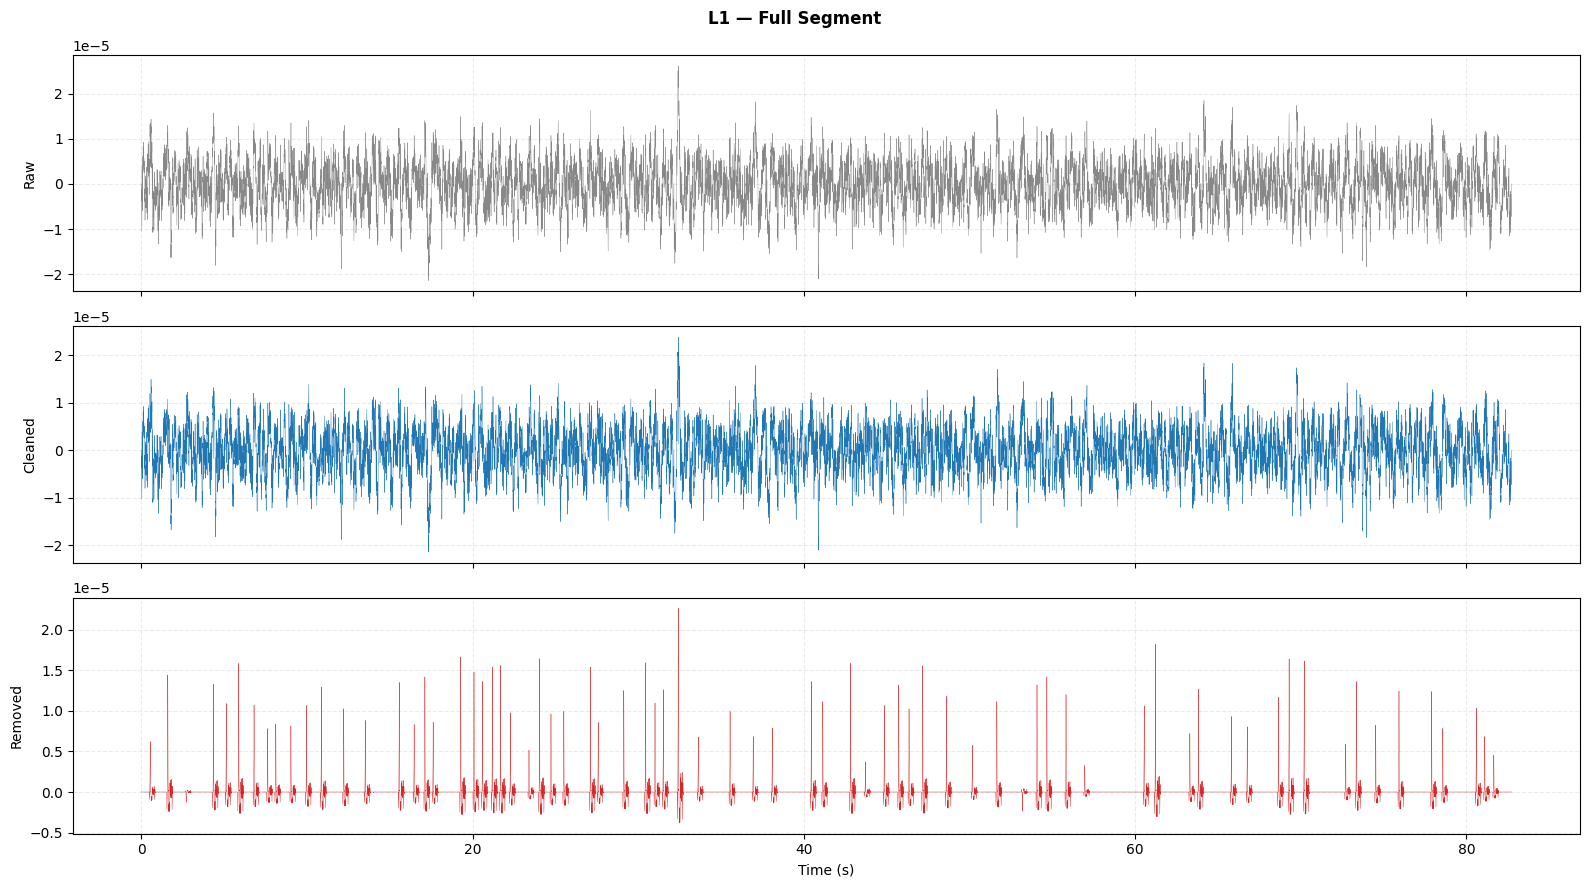

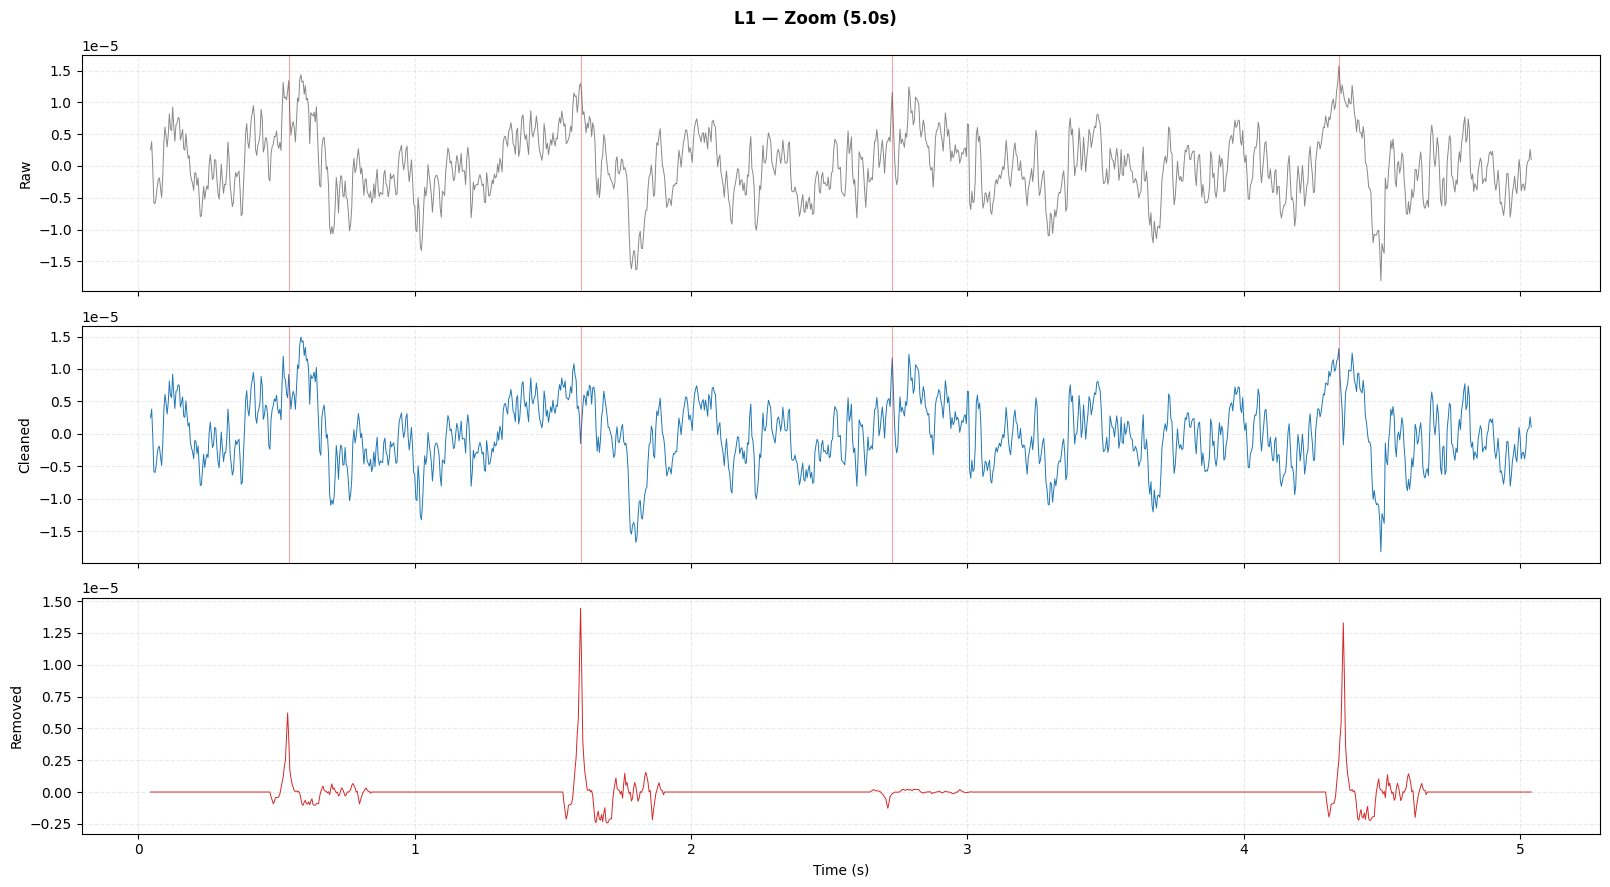

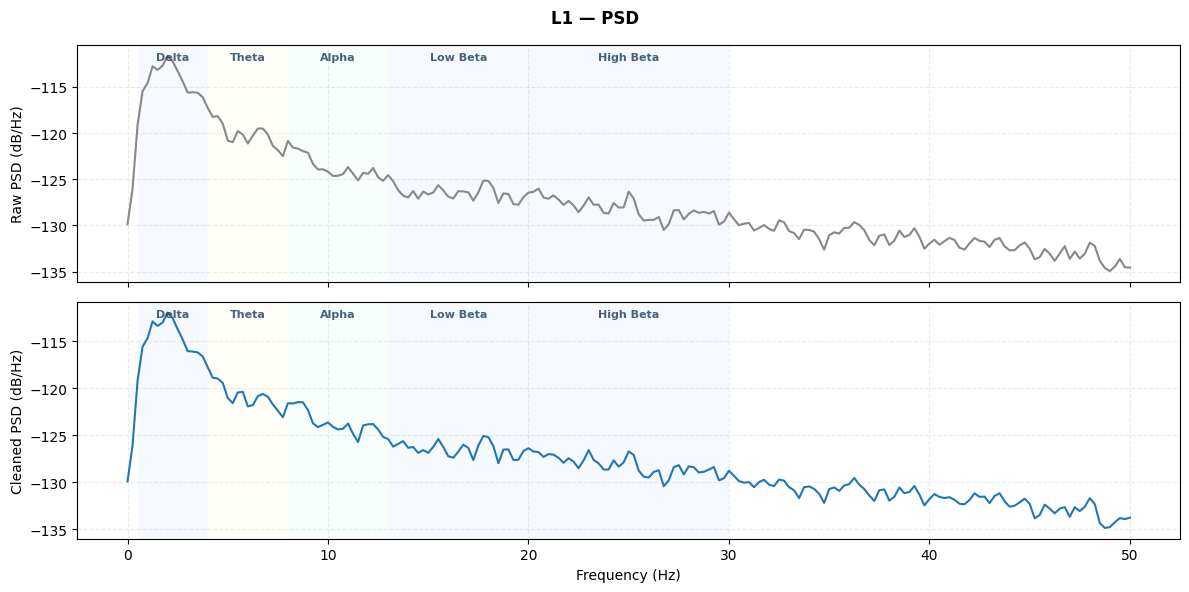

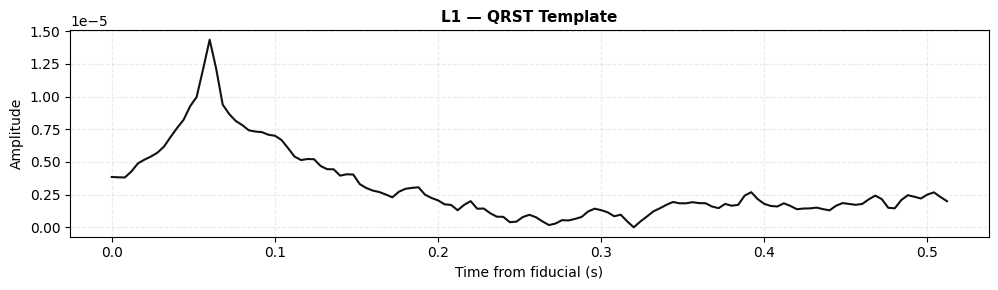

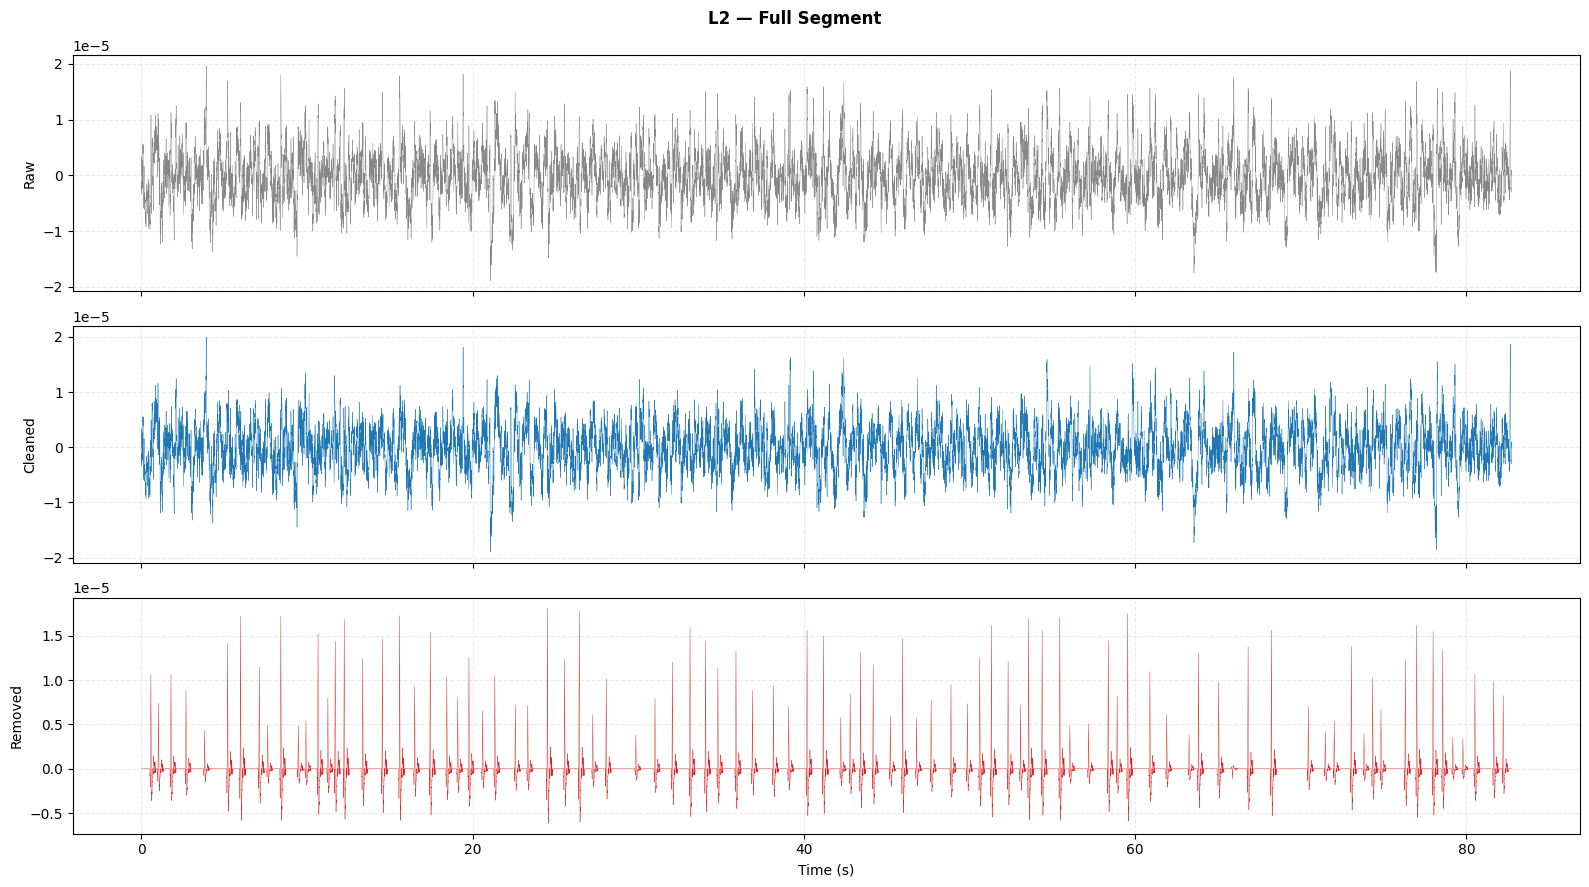

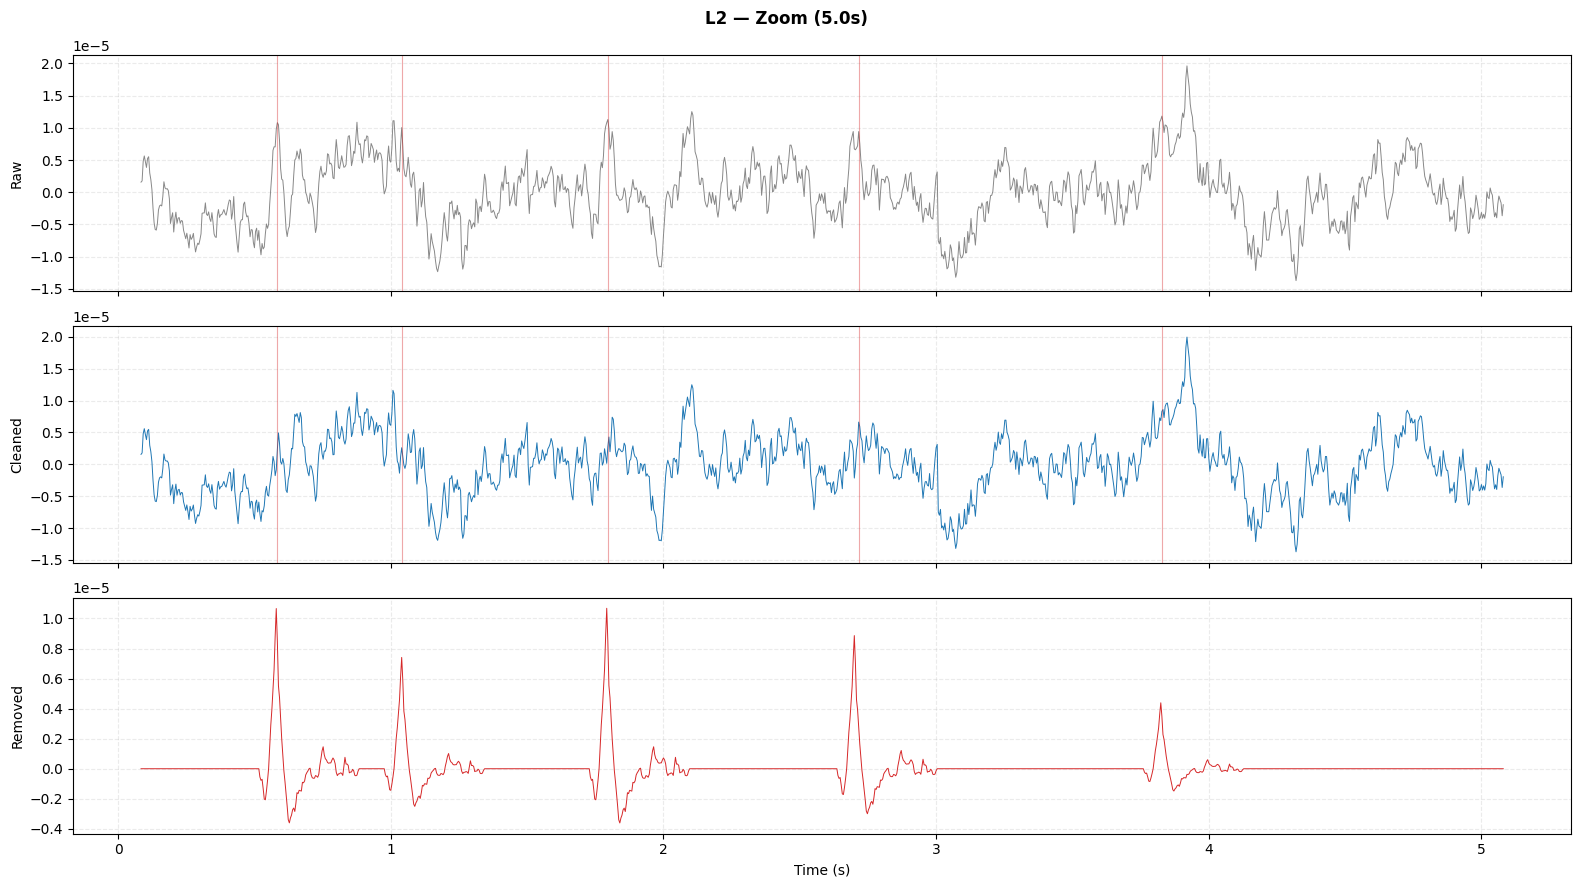

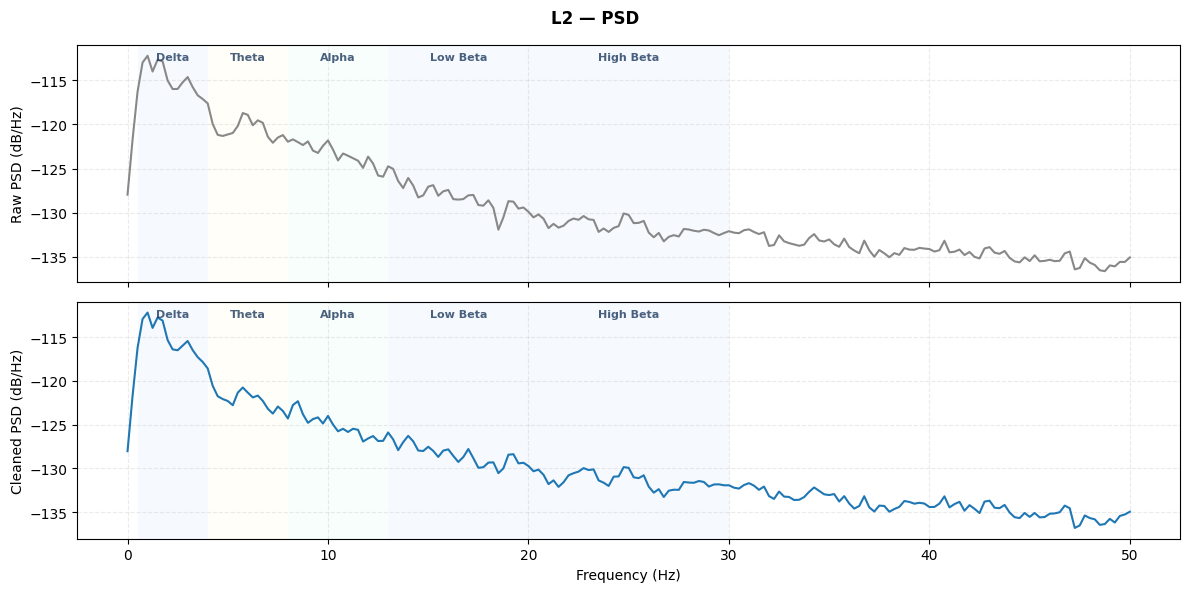

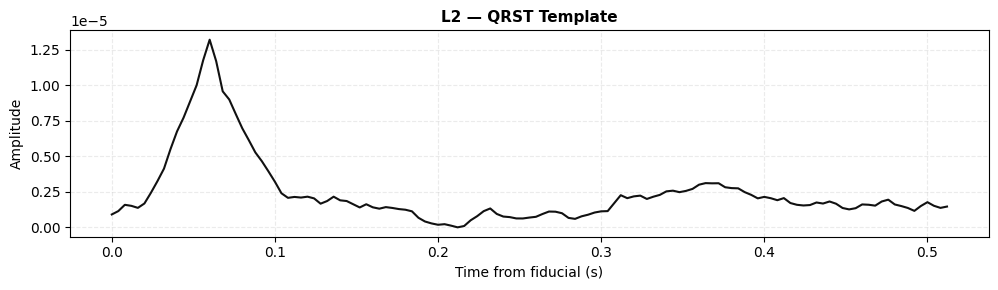

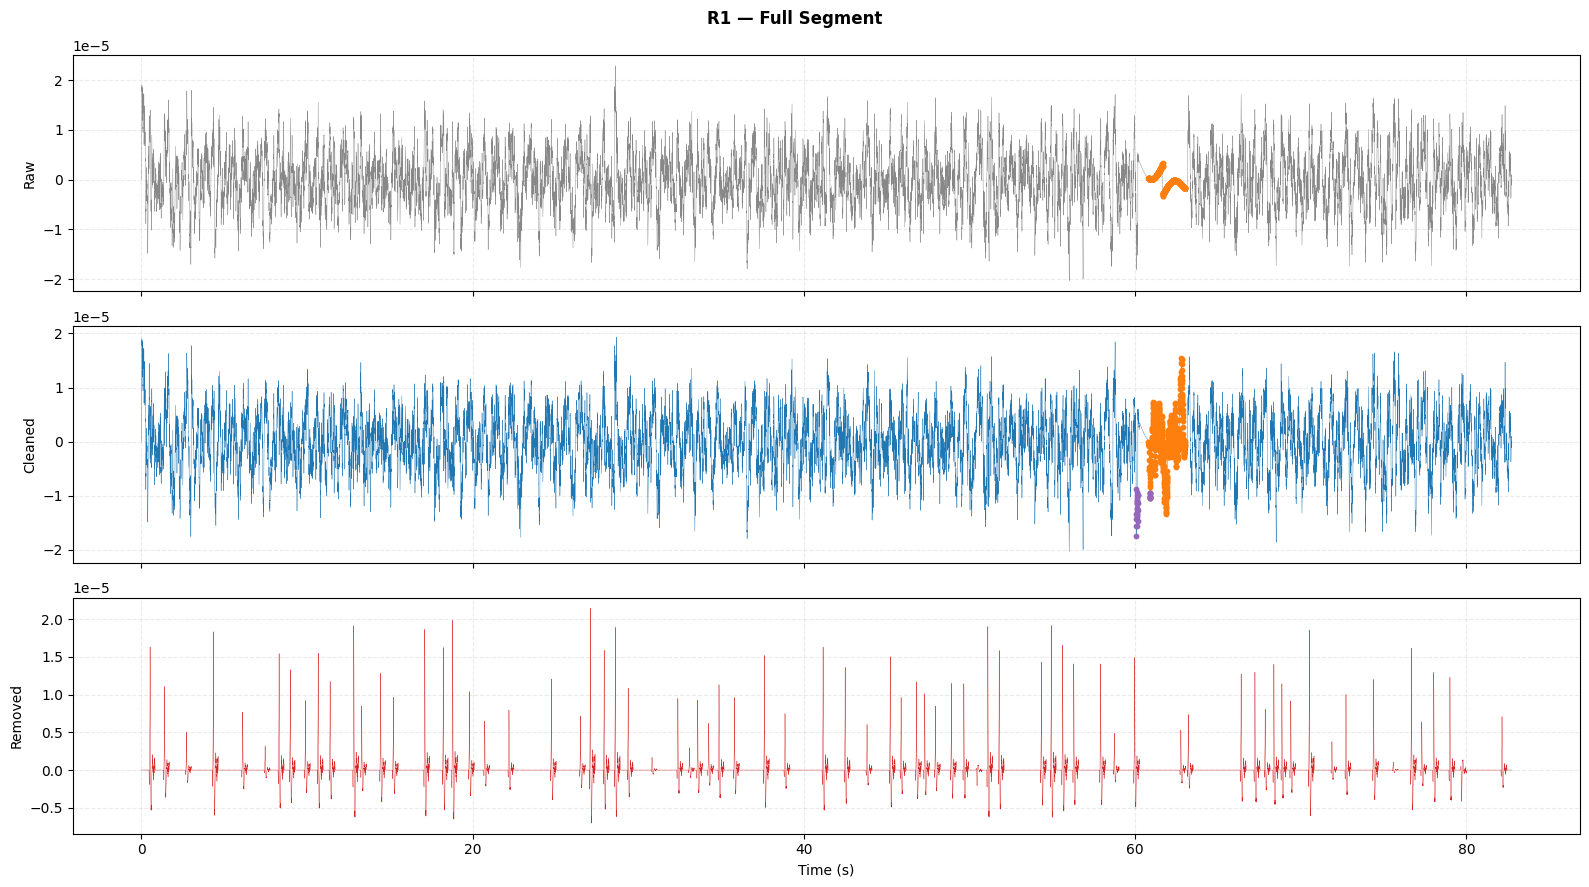

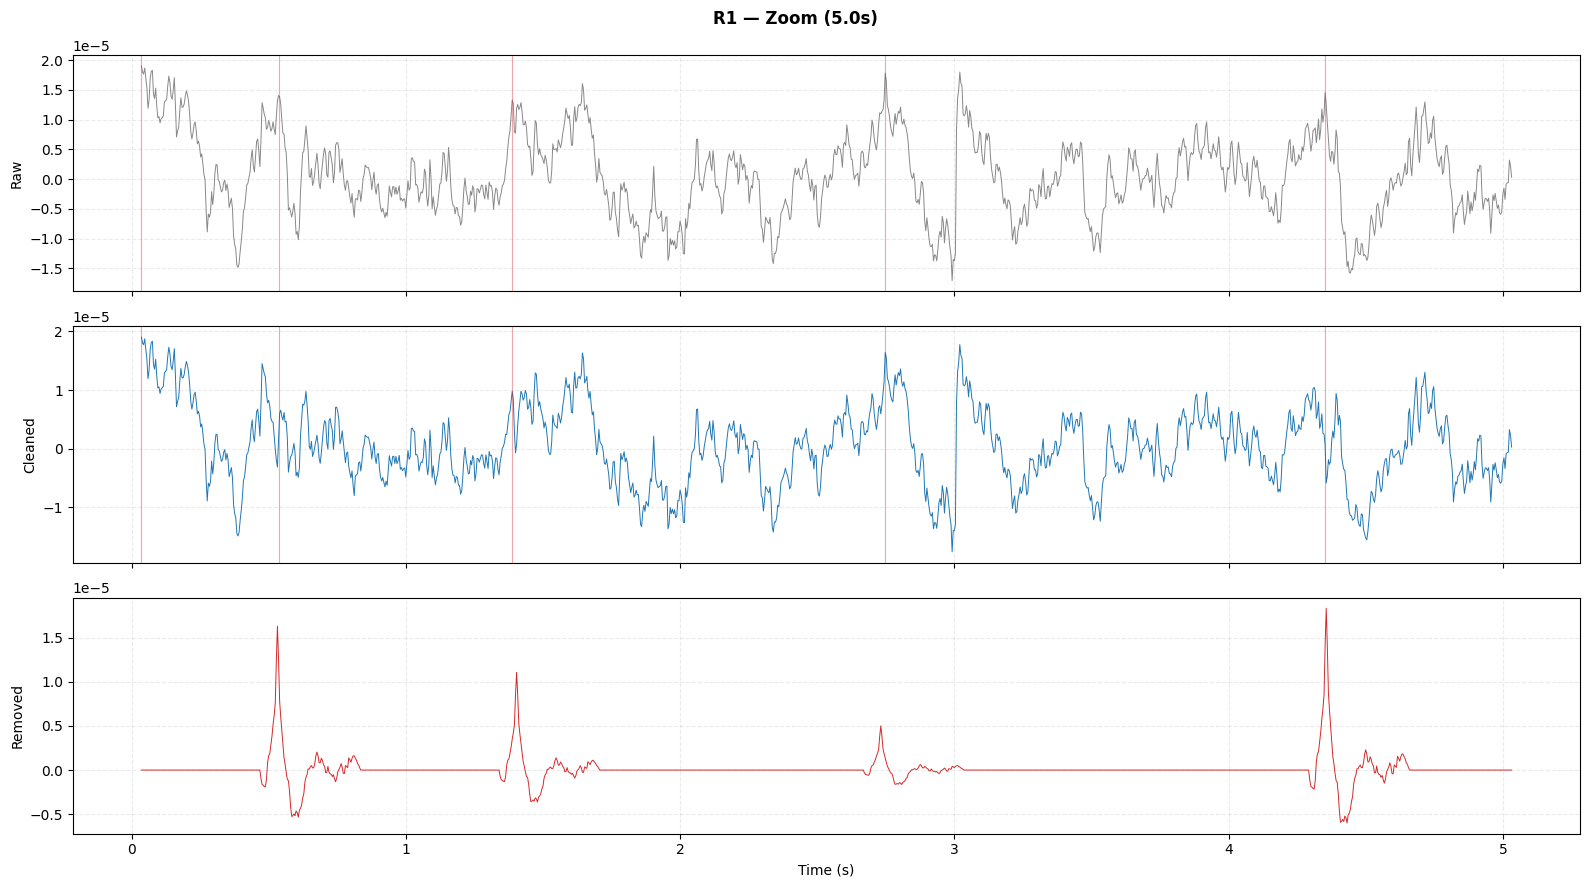

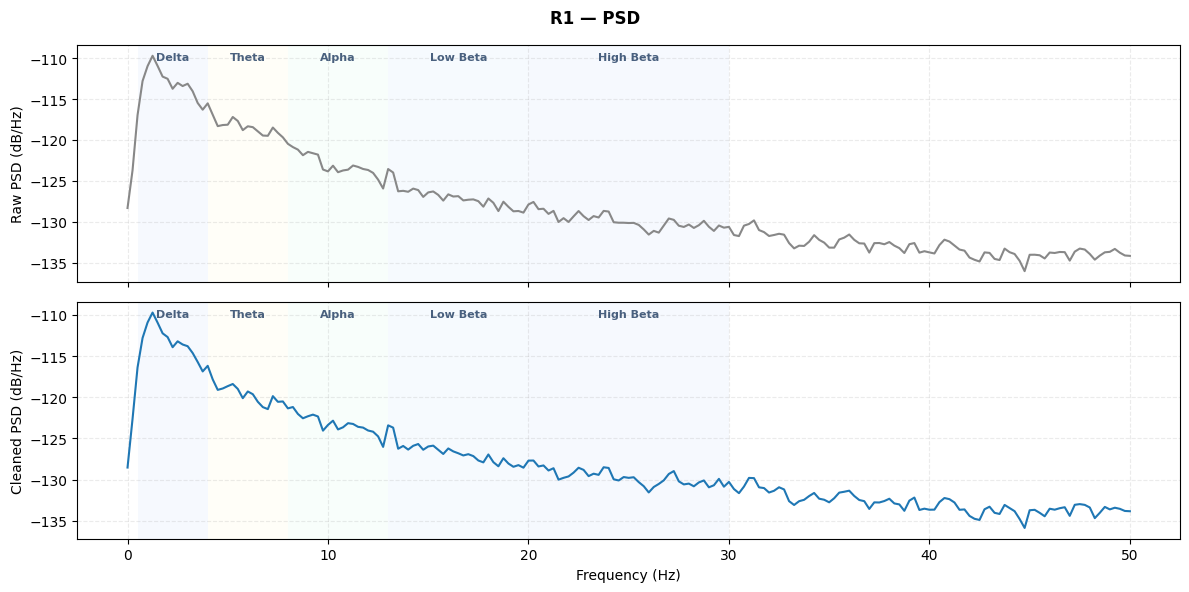

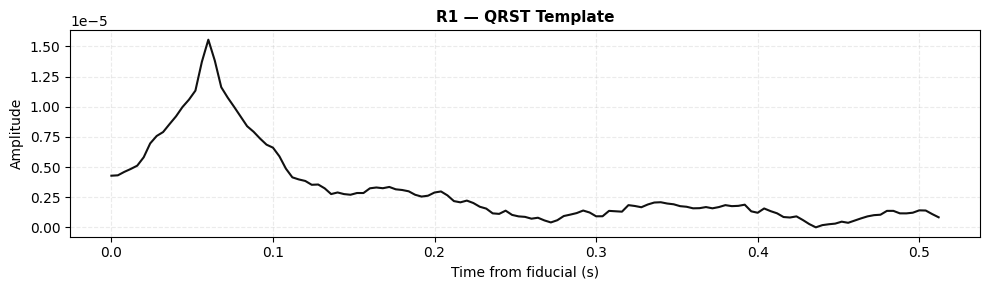

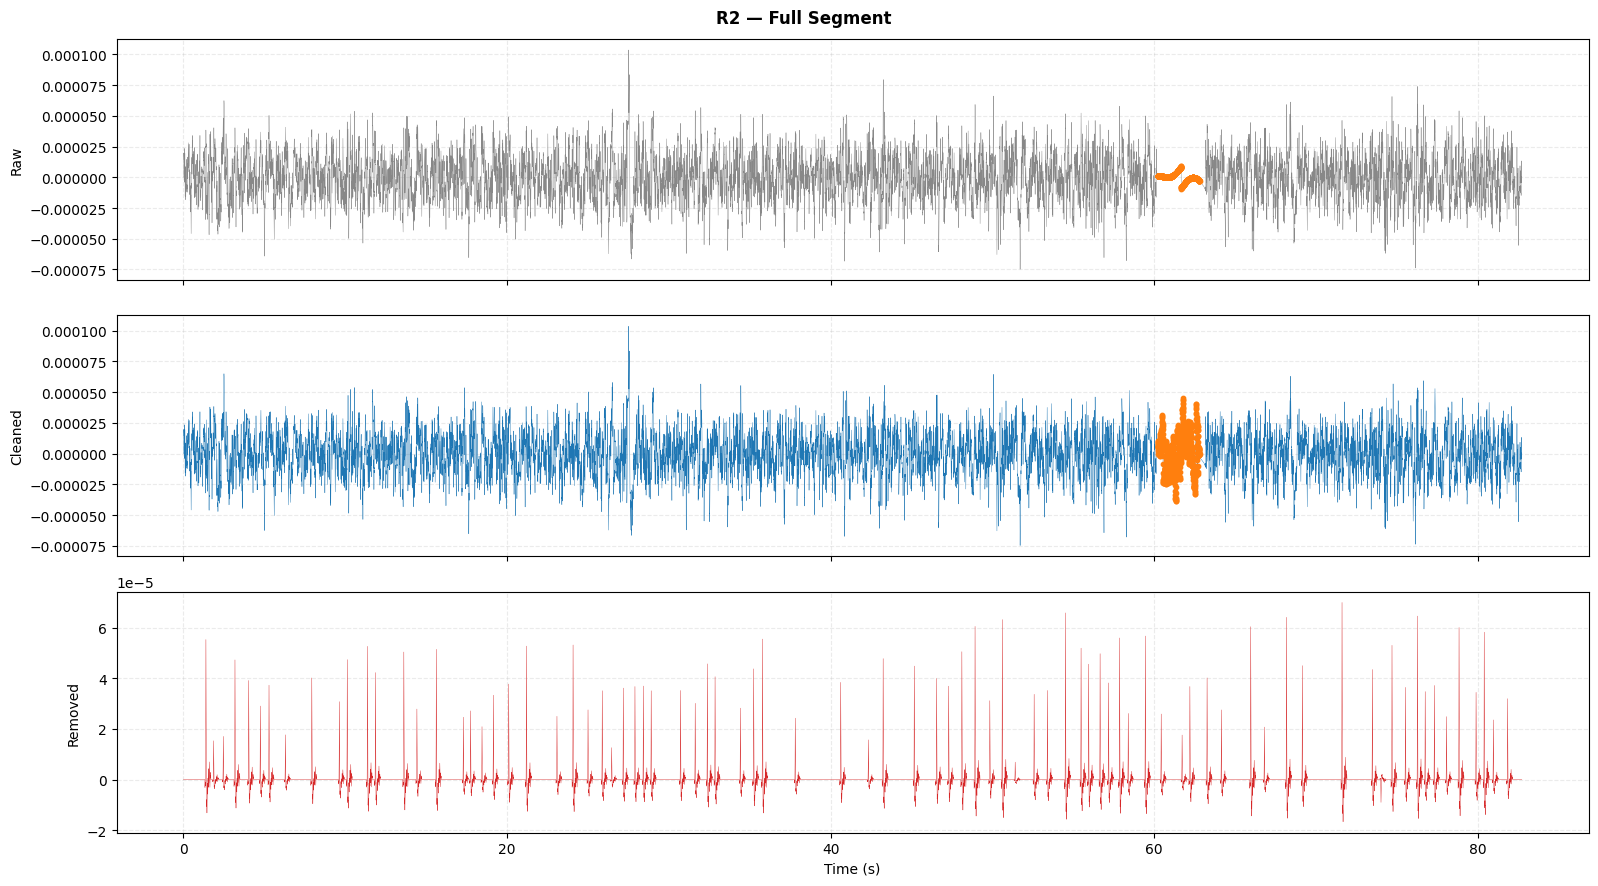

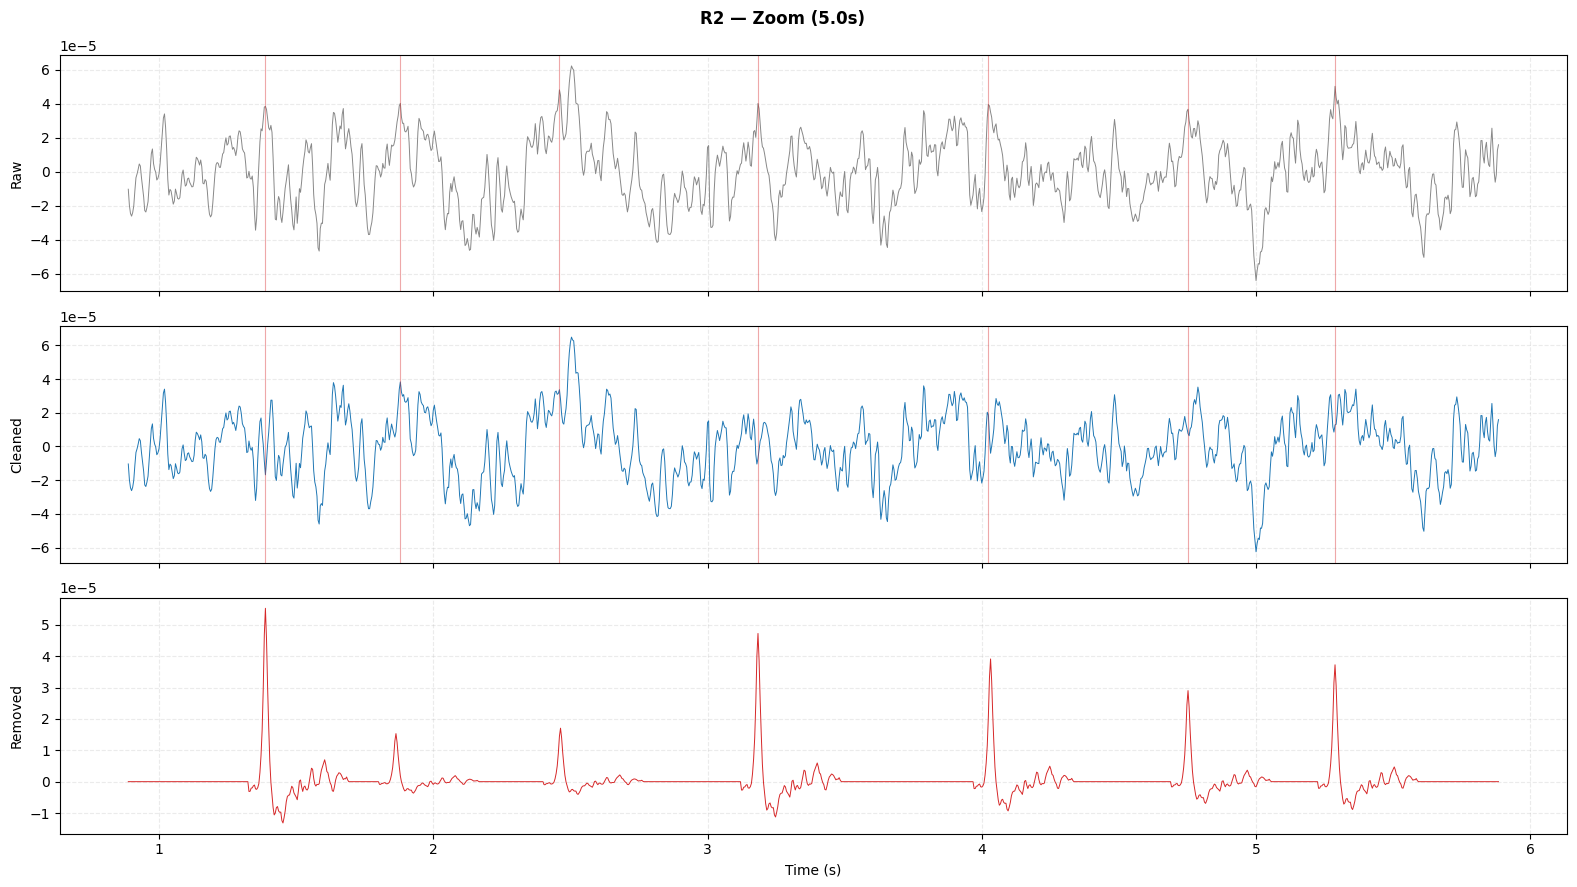

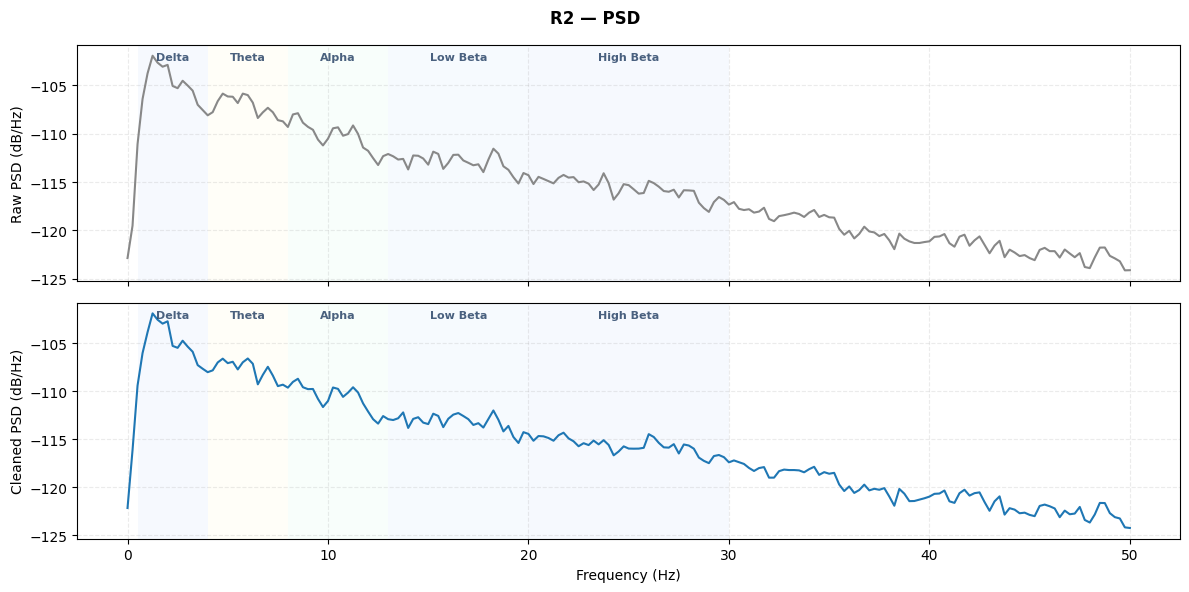

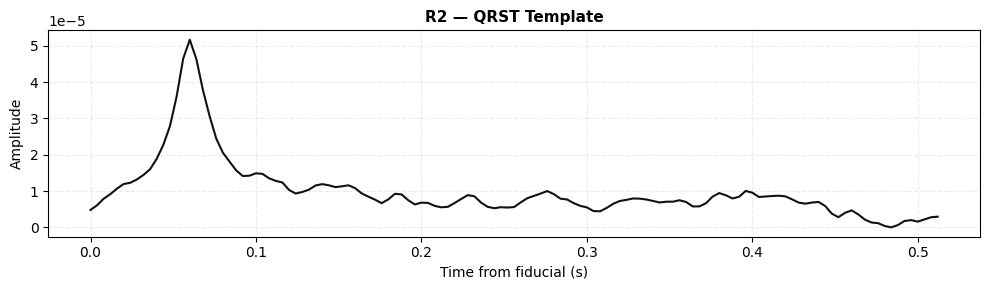

In [2]:
from lfp_xkit import lfp_xkit
from viz_lfp import viz_lfp

result = lfp_xkit(
    fif_path,
    return_removed=True,
    return_raw=True,
    detect_dead_segments=True,
    reconstruct_dead=True,           # Enable spectral reconstruction
    ekg_thr="auto",
    ekg_auto_sensitivity=2.0,
    subtract_t_wave=False,
    qrs_highpass_hz=4.0,
    spike_segment_sec=0.5,
    spike_mad_thresh=8.0,
    dead_segment_sec=0.2,
    min_gap_merge_sec=1.0,
    min_dead_duration_sec=0.3,
    recon_context_sec=2.0,           # 2s of healthy context for PSD
)

# Verify reconstruction worked
print("Reconstructed samples:", result["reconstructed_mask"][0].sum(axis=-1))
print("Dead samples:", result["dead_mask"][0].sum(axis=-1))

from viz_lfp import viz_lfp
viz_lfp(result)
